In [26]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 

In [27]:
#Load Dataset

df = pd.read_csv("cleaned_dataset.csv")
print(df.shape)
df.head()

(103, 20)


,Gender,Course,Study Year,CGPA,Study Days per Week,Study Hours per Day,Study Hours Before Exam,Study Method,Study Schedule,Follow Schedule Frequency,Procrastination Level,Deadline Management,Social Media During Study,Part-Time Job,Work Hours per Week,Study Place,Family Support,Sleep Hours,Stress Level (Beginning of Semester),Stress Level (End of Semester)
0,Male,Bachelor of Education,2,3.5,6,5.5,3.5,Summarizing/making notes,Yes,Always,2,Good,Sometimes,No,0.0,"Library, Room, Campus Study Area",Very Supportive,6.5,2,4
1,Female,Diploma in Computer Science,3,3.5,5,3.5,7.0,Doing practice questions,No,NaN,3,Average,Always,No,0.0,"Library, Room",Very Supportive,4.5,2,4
2,Female,Diploma in Science,2,3.5,7,5.5,7.0,Doing practice questions,Yes,Always,2,Good,Sometimes,No,0.0,Room,Very Supportive,4.5,3,4
3,Female,Bachelor of Information Technology,2,3.5,6,5.5,3.5,Summarizing/making notes,Yes,Sometimes,3,Average,Always,No,0.0,Room,Very Supportive,4.5,2,4
4,Female,Bachelor of Civil Engineering,2,3.5,3,3.5,5.5,Doing practice questions,No,NaN,3,Good,Sometimes,No,0.0,"Room, Campus Study Area",Neutral,3.0,3,4


# Study Hours vs CGPA (Scatter Plot)

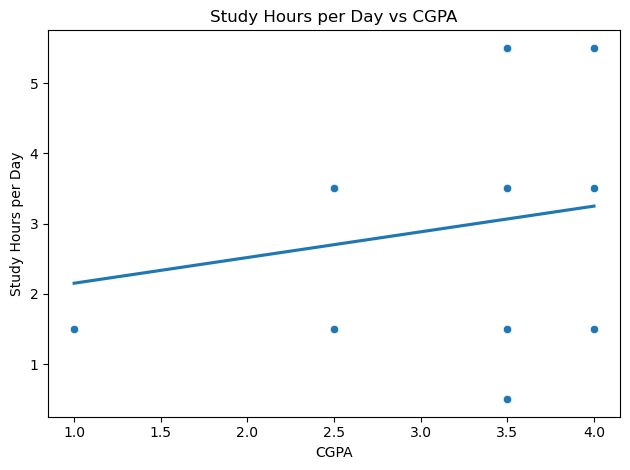

In [38]:
# -----------------------------
# 1. Study Hours vs CGPA (Scatter Plot)
# -----------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x="CGPA",
    y="Study Hours per Day"
)
sns.regplot(
    data=df,
    x="CGPA",
    y="Study Hours per Day",
    scatter=False,
    ci=None
)
plt.title("Study Hours per Day vs CGPA")
plt.xlabel("CGPA")
plt.ylabel("Study Hours per Day")
plt.tight_layout()
plt.show()

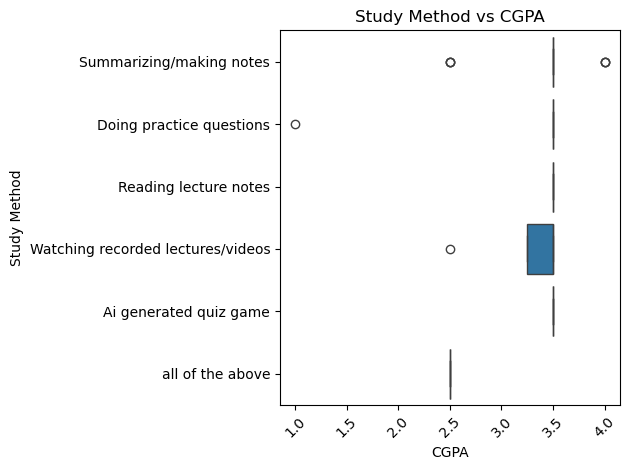

In [37]:
# -----------------------------
# 2. Study Method vs CGPA (Box Plot)
# -----------------------------
plt.figure()
sns.boxplot(
    data=df,
    x="CGPA",
    y="Study Method"
)
plt.title("Study Method vs CGPA")
plt.xlabel("CGPA")
plt.ylabel("Study Method")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


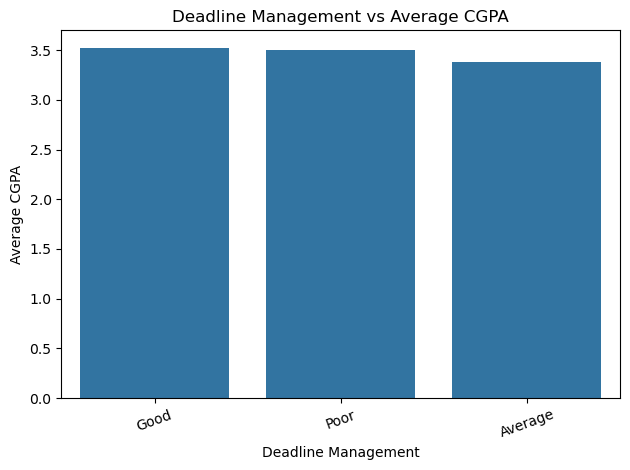

In [30]:
# -----------------------------
# 3.0 Time Management vs CGPA (Bar Chart)
# Using Deadline Management
# -----------------------------
time_mgmt_avg = (
    df.groupby("Deadline Management", as_index=False)["CGPA"]
    .mean()
    .sort_values("CGPA", ascending=False)
)

plt.figure()
sns.barplot(
    data=time_mgmt_avg,
    x="Deadline Management",
    y="CGPA"
)
plt.title("Deadline Management vs Average CGPA")
plt.xlabel("Deadline Management")
plt.ylabel("Average CGPA")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

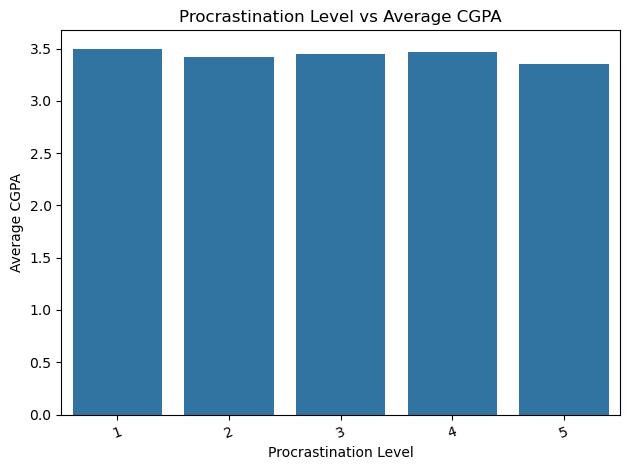

In [31]:
# -----------------------------
# 4. Procrastination vs CGPA (Bar Chart)
# -----------------------------
procrast_avg = (
    df.groupby("Procrastination Level", as_index=False)["CGPA"]
    .mean()
    .sort_values("CGPA", ascending=False)
)

plt.figure()
sns.barplot(
    data=procrast_avg,
    x="Procrastination Level",
    y="CGPA"
)
plt.title("Procrastination Level vs Average CGPA")
plt.xlabel("Procrastination Level")
plt.ylabel("Average CGPA")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

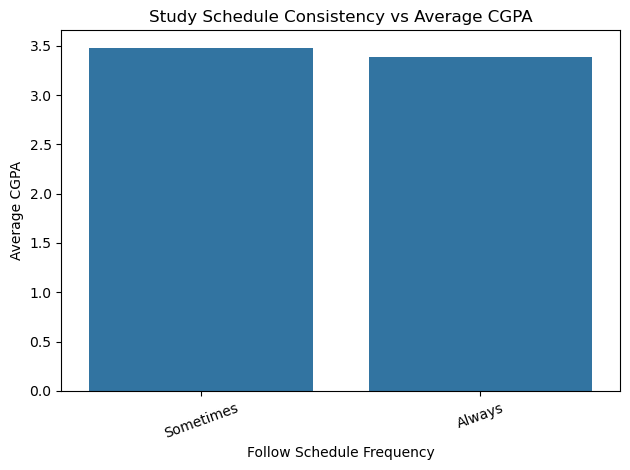

In [32]:
# -----------------------------
# 5. Study Schedule Consistency vs CGPA (Bar Chart)
# Using Follow Schedule Frequency
# -----------------------------
schedule_avg = (
    df.groupby("Follow Schedule Frequency", as_index=False)["CGPA"]
    .mean()
    .sort_values("CGPA", ascending=False)
)

plt.figure()
sns.barplot(
    data=schedule_avg,
    x="Follow Schedule Frequency",
    y="CGPA"
)
plt.title("Study Schedule Consistency vs Average CGPA")
plt.xlabel("Follow Schedule Frequency")
plt.ylabel("Average CGPA")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

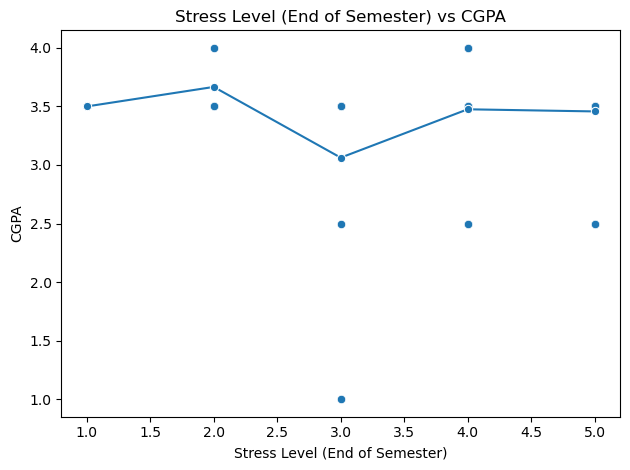

In [33]:

# -----------------------------
# 6. Stress vs CGPA (Scatter/Line Chart)
# -----------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x="Stress Level (End of Semester)",
    y="CGPA"
)

stress_avg = (
    df.groupby("Stress Level (End of Semester)", as_index=False)["CGPA"]
    .mean()
    .sort_values("Stress Level (End of Semester)")
)

sns.lineplot(
    data=stress_avg,
    x="Stress Level (End of Semester)",
    y="CGPA",
    marker="o"
)
plt.title("Stress Level (End of Semester) vs CGPA")
plt.xlabel("Stress Level (End of Semester)")
plt.ylabel("CGPA")
plt.tight_layout()
plt.show()


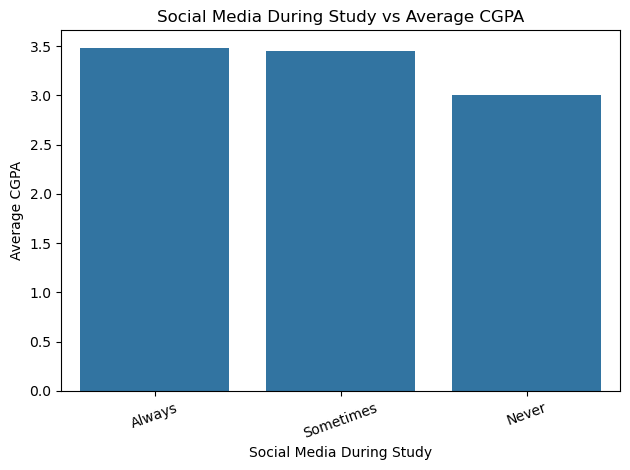

In [34]:
# -----------------------------
# 7. Social Media Usage vs CGPA (Bar Chart)
# -----------------------------
social_avg = (
    df.groupby("Social Media During Study", as_index=False)["CGPA"]
    .mean()
    .sort_values("CGPA", ascending=False)
)

plt.figure()
sns.barplot(
    data=social_avg,
    x="Social Media During Study",
    y="CGPA"
)
plt.title("Social Media During Study vs Average CGPA")
plt.xlabel("Social Media During Study")
plt.ylabel("Average CGPA")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

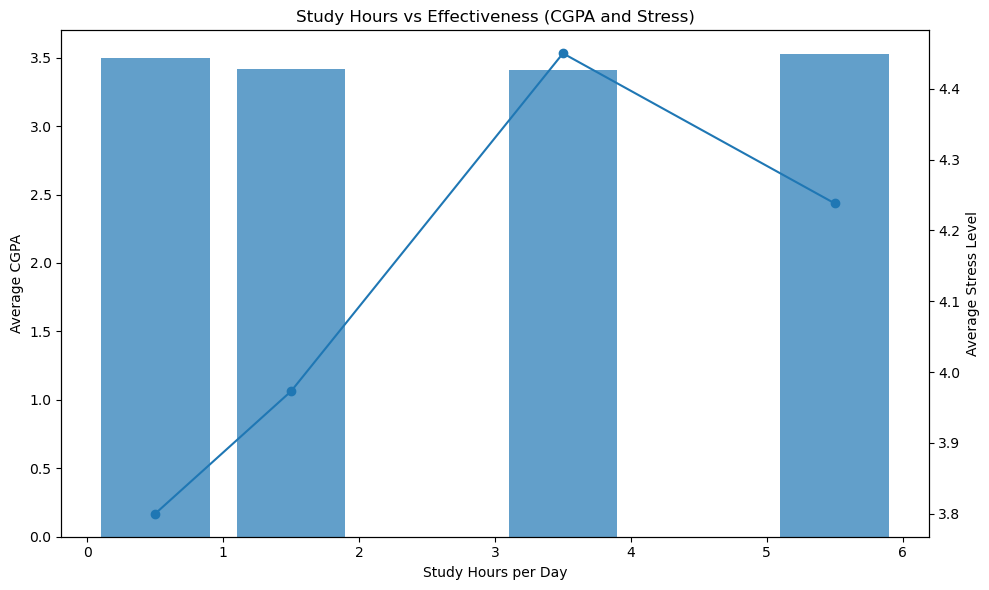

In [35]:
# -----------------------------
# 8. Study Hours vs Effectiveness (Combined / Dual-axis)
# Effectiveness shown using avg CGPA + avg stress by study hours
# -----------------------------
combined = (
    df.groupby("Study Hours per Day", as_index=False)
    .agg({
        "CGPA": "mean",
        "Stress Level (End of Semester)": "mean"
    })
    .sort_values("Study Hours per Day")
)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(
    combined["Study Hours per Day"],
    combined["CGPA"],
    alpha=0.7,
    label="Average CGPA"
)
ax1.set_xlabel("Study Hours per Day")
ax1.set_ylabel("Average CGPA")

ax2 = ax1.twinx()
ax2.plot(
    combined["Study Hours per Day"],
    combined["Stress Level (End of Semester)"],
    marker="o"
)
ax2.set_ylabel("Average Stress Level")

plt.title("Study Hours vs Effectiveness (CGPA and Stress)")
fig.tight_layout()
plt.show()